<div style="display: flex; align-items: center; width: 100%;">
  <div style="display: flex; flex-direction: column; align-items: center; justify-content: center; width: 100px; margin-right: 0px;">
    <a href="https://risklab.ai" style="border: 0; line-height: 0.5;">
      <img src="../Utils/risklab_ai.gif" width="60px" style="border: 0; margin-bottom:-10px; vertical-align: middle;"/>
    </a>
  </div>
  <div style="flex-grow: 1;">
    <h1 style="margin: 0; margin-left:0; font-weight: bold; text-align: left; font-size: 38px;">
      Debiased feature importance: MDI+ and CPI
    </h1>
  </div>
</div>

De Prado's **MDI** counts impurity reduction, which inflates with split
opportunities (high cardinality) and in-sample reuse, so it over-credits noisy /
continuous features and can rank noise above signal. **MDA** has no significance
test. Two fixes: **MDI+** (Agarwal et al. 2023) recasts each tree's MDI as a
regularized GLM on its decision-stump basis scored out-of-bag, removing the
inflation; **CPI** (Watson-Wright 2021) gives conditional, performance-based
importance with a calibrated knockoff significance test.

*Baseline (MDI/MDA) -> where it breaks (cardinality inflation, no test) -> MDI+/CPI.*

In [1]:
using Pkg
Pkg.activate(joinpath(@__DIR__, ".."))   # the pinned notebook environment

using Random, Statistics, Plots
gr()
theme(:default)                            # theme-adaptive figures (legible on light & dark)
default(background_color = :transparent, background_color_inside = :transparent,
        foreground_color = "#888888", gridalpha = 0.3,
        legend_background_color = :transparent)
using RiskLabAI.Features: feature_importance_mdi, mdi_plus_importance,
    conditional_predictive_impact

  Activating project at `C:\risklab\risklabai\Notebooks.jl`


## 1. A dataset with a high-cardinality noise trap
Feature 1 is informative. Feature 2 is **pure noise but high-cardinality**
(continuous), exactly the kind of feature plain MDI over-credits. Feature 3 is
low-cardinality noise.

In [2]:
rng = MersenneTwister(7)
n = 600
y = rand(rng, 0:1, n)
x = hcat(Float64.(y) .+ 0.6 .* randn(rng, n),   # 1: informative
         randn(rng, n),                          # 2: high-cardinality noise
         Float64.(rand(rng, 0:1, n)))            # 3: low-cardinality noise
labels = ["informative", "hi-card noise", "lo-card noise"]
mdi = feature_importance_mdi(x, y; n_trees = 80, random_state = 1)
mdiplus = mdi_plus_importance(x, y; n_trees = 80, random_state = 1)
for j in 1:3
    println(rpad(labels[j], 16), " MDI=", round(mdi.mean[j], digits=4),
            "   MDI+=", round(mdiplus[j], digits=4))
end

informative      MDI=0.6622   MDI+=0.1153
hi-card noise    MDI=0.3284   MDI+=0.0048
lo-card noise    MDI=0.0094   MDI+=0.0005


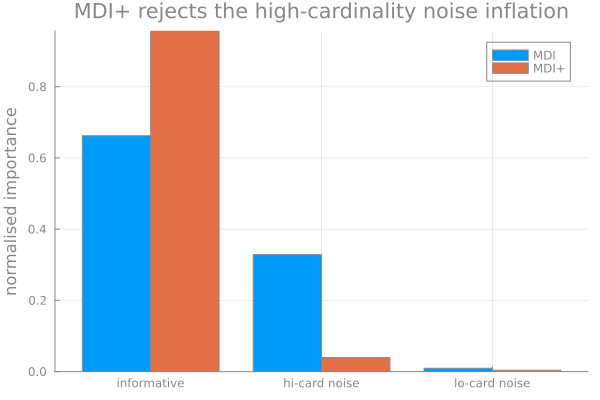

In [3]:
xs = 1:3
bar(xs .- 0.2, mdi.mean ./ sum(mdi.mean); bar_width = 0.4, label = "MDI",
    xticks = (collect(xs), labels), ylabel = "normalised importance",
    title = "MDI+ rejects the high-cardinality noise inflation", legend = :topright)
bar!(xs .+ 0.2, mdiplus ./ sum(mdiplus); bar_width = 0.4, label = "MDI+")

## 2. CPI: a calibrated test of whether a feature matters
CPI reports a per-feature importance (mean log-loss increase under a knockoff)
**and** a one-sided p-value, the significance test MDA lacks.

In [4]:
cpi = conditional_predictive_impact(x, y; n_splits = 4, n_trees = 60, random_state = 1)
for j in 1:3
    println(rpad(labels[j], 16), " CPI=", round(cpi.importance[j], digits=4),
            "   p=", round(cpi.p_value[j], digits=4))
end

informative      CPI=1.6113   p=0.0
hi-card noise    CPI=-0.0255   p=0.5689
lo-card noise    CPI=-0.1964   p=0.9822


## When to use / when NOT (from `appraisals/10_verdict.md`)
**Prefer MDI+ over MDI when features are noisy, high-cardinality, or mixed-type**
- it rejects noise/cardinality inflation (noise-rejection 0.94 vs MDI 0.50) and
recovers true relevance better; it converges to MDI when features are orthogonal
and high-SNR. **Prefer CPI when a statistically valid test of whether a feature
matters is needed** (MDA has none): nominal size, good power. (Behavioural port on
the DecisionTree.jl backend, validated structurally.)